In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks


[Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks'
/content


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from collections import Counter

# 2. Standard Flower Name Mapping (Oxford 102 species)
# This mapping is standard for this dataset.
flower_names = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea", "english marigold",
    "tiger lily", "moon orchid", "bird of paradise", "monkshood", "globe thistle",
    "snapdragon", "colt's foot", "king protea", "spear thistle", "yellow iris",
    "globe-flower", "purple coneflower", "peruvian lily", "balloon flower", "giant white arum lily",
    "fire lily", "pincushion flower", "fritillary", "red ginger", "grape hyacinth",
    "corn poppy", "prince of wales feathers", "stemless gentian", "artichoke", "sweet william",
    "carnation", "garden phlox", "love in the mist", "mexican aster", "alpine sea holly",
    "ruby-lipped cattleya", "cape flower", "great masterwort", "siam tulip", "lenten rose",
    "barbeton daisy", "daffodil", "sword lily", "poinsettia", "ステマ (bolero deep blue)",
    "wallflower", "marigold", "buttercup", "oxeye daisy", "common dandelion",
    "mexican petunia", "wild pansy", "primula", "sunflower", "pelargonium",
    "bishop of llandaff", "gaura", "geranium", "orange dahlia", "pink-yellow dahlia",
    "cautleya spicata", "japanese anemone", "black-eyed susan", "silverbush", "californian poppy",
    "osteospermum", "spring crocus", "bearded iris", "windflower", "tree poppy",
    "gazania", "azalea", "water lily", "rose", "thorn apple",
    "morning glory", "passion flower", "lotus", "toad lily", "anthurium",
    "frangipani", "clematis", "hibiscus", "columbine", "desert-rose",
    "tree mallow", "magnolia", "cyclamen", "watercress", "canna lily",
    "hippeastrum", "bee balm", "ball moss", "foxglove", "bougainvillea",
    "camellia", "mallow", "mexican creaster", "bromelia", "blanket flower",
    "trumpet creeper", "blackberry lily"
]


# Load [Datasets](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html#torchvision.datasets.Flowers102)

In [2]:
raw_set = datasets.Flowers102(root='data', split='test', download=True)
raw_test_set= datasets.Flowers102(root='data', split='train', download=True)
raw_val_set = datasets.Flowers102(root='data', split='val', download=True)


100%|██████████| 345M/345M [00:11<00:00, 28.8MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.16MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 29.1MB/s]


I noticed that the split argument for test and train is switched. the train set have only 10 images in each class while the test set have an unbalanced image for each class. So I switch their annotate that the `train_set` have `split=test` while `test_set` have `split=train`

# EDA: Class Distribution

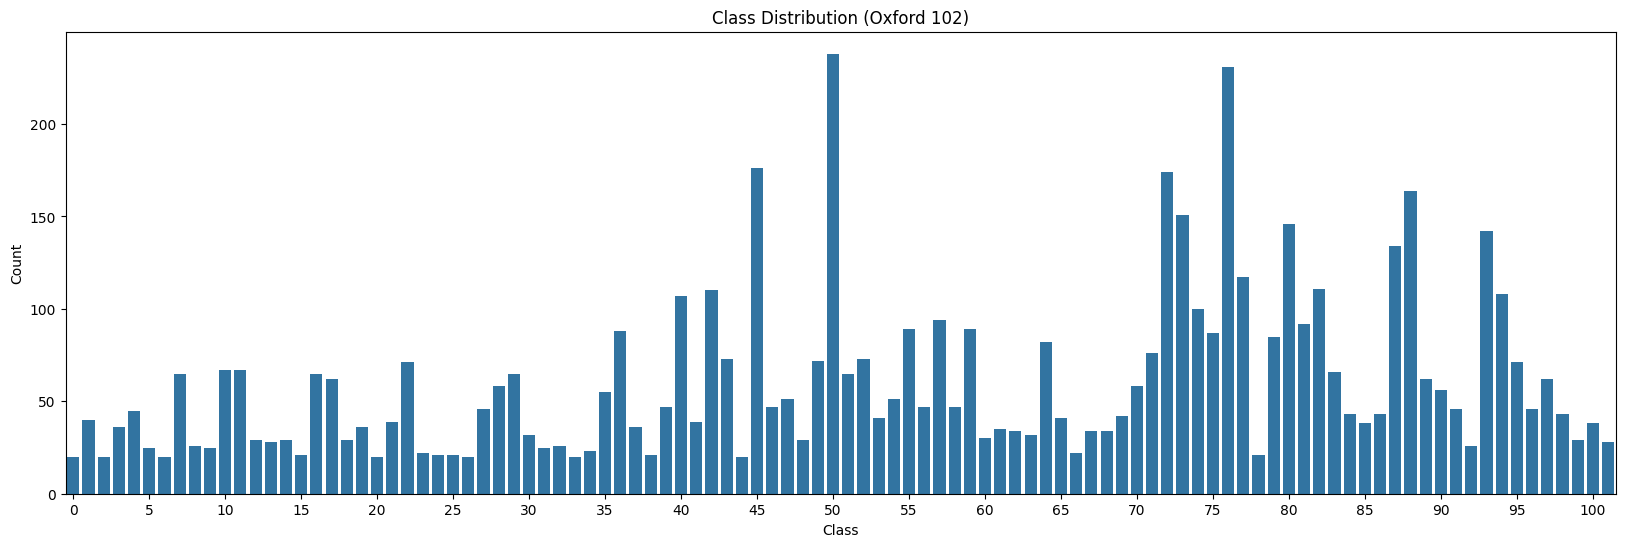

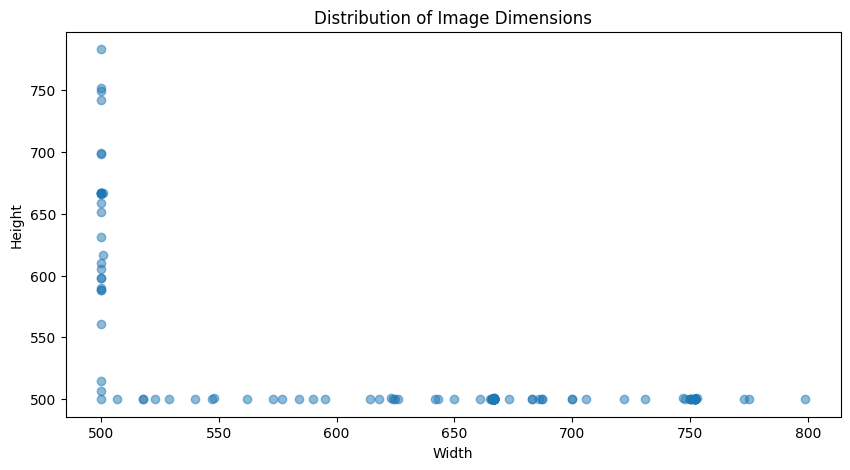

In [3]:
import pandas as pd
import seaborn as sns
from PIL import Image

def analyze_dataset_quality(dataset):
    labels = dataset._labels
    counts = Counter(labels)

    # 1. Class Distribution
    df_dist = pd.DataFrame({'Class': list(counts.keys()), 'Count': list(counts.values())})
    plt.figure(figsize=(20, 6))
    sns.barplot(data=df_dist, x='Class', y='Count')
    plt.title("Class Distribution (Oxford 102)")
    plt.xticks(range(0, 102, 5))
    plt.show()

    # 2. Image Dimension Analysis
    # We sample a portion to save time in Colab
    dims = []
    for i in range(0, len(dataset), 50):
        img, _ = dataset[i]
        dims.append(img.size) # (width, height)

    widths, heights = zip(*dims)
    plt.figure(figsize=(10, 5))
    plt.scatter(widths, heights, alpha=0.5)
    plt.title("Distribution of Image Dimensions")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()

analyze_dataset_quality(raw_set)

The data distribution seems to be uneven. I will use Weighted Random Sampler in Part 2 to ensure the model doesn't ignore underrepresented species.



In [5]:
import scipy.io

# Load the labels
mat = scipy.io.loadmat('/content/data/flowers-102/imagelabels.mat')

# Extract the labels array (usually stored under the key 'labels')
labels = mat['labels'][0]

print(f"Total labels found: {len(labels)}")
print(f"First 10 labels: {labels[:10]}")

Total labels found: 8189
First 10 labels: [77 77 77 77 77 77 77 77 77 77]


Image 7599 is: camellia


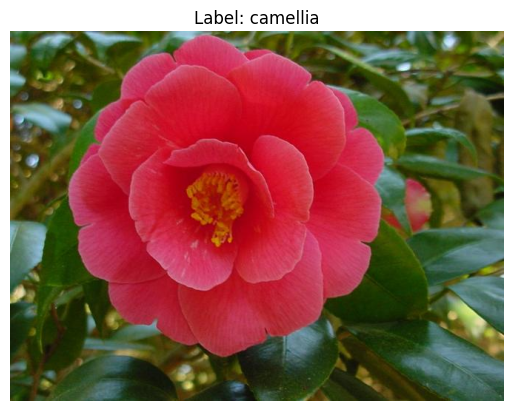

In [7]:
import scipy.io

# 1. Load the labels from the .mat file
labels_mat = scipy.io.loadmat('/content/data/flowers-102/imagelabels.mat')
labels = labels_mat['labels'][0]  # This is an array of numbers (1-102)

# 2. Pick an image index (e.g., image 0)
image_index = 7598
label_num = labels[image_index]

# 3. Map to the name (subtract 1 because list indices start at 0)
print(f"Image {image_index + 1} is: {flower_names[label_num - 1]}")

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Assuming your images are in a folder named 'jpg' and named 'image_00001.jpg', etc.
img_path = f"/content/data/flowers-102/jpg/image_{image_index+1:05d}.jpg"
img = mpimg.imread(img_path)

plt.imshow(img)
plt.title(f"Label: {flower_names[label_num - 1]}")
plt.axis('off')
plt.show()